# Diffusion + perceptual loss: a first small test

`style_transfer/loss.py`'s `perceptual_loss(generated_images, content_images, style_images, ...)` is already decoupled from the generator that produces `generated_images` — it just scores whatever image tensor you hand it against content/style targets via VGG features. That's the property CLAUDE.md's Goals section calls out as the prerequisite for scoring "a diffusion model's denoised output" with the same perceptual approach.

This notebook is the smallest possible test of that idea:

1. Train a tiny, content-conditioned DDPM-style diffusion model to denoise towards a single content image (`artifacts/images/content/flowers/lily6.jpeg`).
2. At every training step, also run `perceptual_loss` on the model's *predicted* clean image (`x0`) against the content image and a style image (`artifacts/images/singles/wave-of-kanagawa.jpg`), and add that as an auxiliary loss term.
3. Sample from the trained model and see whether the output looks stylized.

**This is a toy, single-image overfit experiment**, not a real generative model — the point is only to check whether `perceptual_loss` provides a usable training signal through a diffusion model's predicted-x0, before investing in a proper multi-image training setup. See the notes cell at the end for what a real version would need.

The diffusion architecture lives entirely in this notebook, not in `style_transfer/`, since diffusion implementation is explicitly a long-term/exploratory goal in CLAUDE.md, not part of the library yet.

In [1]:
import sys
from pathlib import Path

# walk up from the notebook's cwd until we find the repo root (style_transfer/)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "style_transfer").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image

from style_transfer.dataset import SingleImageDataset
from style_transfer.inference import select_device, postprocess
from style_transfer.feature_extractors.vgg import initialize_vgg
from style_transfer.loss import perceptual_loss

DEVICE = select_device()
print(f"Using device: {DEVICE}")

Using device: mps


## Config

Kept deliberately small so this trains in a couple of minutes on CPU/MPS.

In [2]:
CONTENT_PATH = REPO_ROOT / "artifacts/images/content/flowers/lily6.jpeg"
STYLE_PATH = REPO_ROOT / "artifacts/images/singles/wave-of-kanagawa.jpg"
OUTPUT_DIR = REPO_ROOT / "outputs/quick_test/diffusion_experiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 128          # small + fast; must be divisible by 4 for the tiny UNet's two downsamples
NUM_TIMESTEPS = 200       # short diffusion schedule, not a production DDPM setting
TRAIN_STEPS = 300         # single-image overfit run, not a real training set
LR = 2e-4
STYLE_WEIGHT = 1e5        # same scale style_transfer.train.py uses for the feed-forward model
PERCEPTUAL_WEIGHT = 1e-2  # balances perceptual_loss's magnitude against the eps-prediction MSE loss

## Load content + style images

Reusing `SingleImageDataset` (the same resize+`ToTensor` pipeline `train.py` uses) keeps this in lockstep with the rest of the library — plain `[0, 1]`-range tensors, no extra scaling. That's the exact class of bug CLAUDE.md's Goals section flags as previously broken (`*255` mismatch between train/inference), so the diffusion process below is deliberately kept in the same `[0, 1]` range rather than the more common `[-1, 1]` DDPM convention.

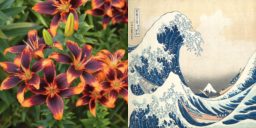

In [3]:
content_tensor = SingleImageDataset(str(CONTENT_PATH), IMAGE_SIZE, DEVICE, quiet=True)[0].unsqueeze(0).to(DEVICE)
style_tensor = SingleImageDataset(str(STYLE_PATH), IMAGE_SIZE, DEVICE, quiet=True)[0].unsqueeze(0).to(DEVICE)

def side_by_side(*tensors):
    imgs = [postprocess(t.squeeze(0).cpu()) for t in tensors]
    widths, heights = zip(*(im.size for im in imgs))
    canvas = Image.new("RGB", (sum(widths), max(heights)))
    x = 0
    for im in imgs:
        canvas.paste(im, (x, 0))
        x += im.width
    return canvas

side_by_side(content_tensor, style_tensor)

## VGG feature extractor

Same global VGG setup `train.py` uses — `perceptual_loss` reads from it via `get_vgg_model()`.

In [4]:
initialize_vgg(layer_preset="standard", device=DEVICE)

## Tiny content-conditioned UNet

A minimal denoiser: two downsample levels, one bottleneck, one skip connection, sinusoidal timestep embedding injected additively after each block's first conv. Content conditioning is done the simplest possible way — the content image is concatenated to the noisy input on the channel axis, so the model always sees what it's supposed to be denoising towards.

In [5]:
import math

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return self.act(self.norm2(self.conv2(h)))


class TinyUNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=3, base_ch=32, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.down1 = ConvBlock(in_channels, base_ch, time_dim)
        self.down2 = ConvBlock(base_ch, base_ch * 2, time_dim)
        self.pool = nn.AvgPool2d(2)
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 2, time_dim)
        self.up1 = ConvBlock(base_ch * 2 + base_ch * 2, base_ch, time_dim)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.out_conv = nn.Conv2d(base_ch, out_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h1 = self.down1(x, t_emb)
        h2 = self.down2(self.pool(h1), t_emb)
        b = self.upsample(self.bottleneck(self.pool(h2), t_emb))
        u1 = self.upsample(self.up1(torch.cat([b, h2], dim=1), t_emb))
        return self.out_conv(u1)

## Diffusion schedule

Standard linear-beta DDPM forward process, staying in `[0, 1]` image space throughout (see note above). `predict_x0` inverts the forward process to recover the model's current best guess at the clean image from its noise prediction — that's the tensor `perceptual_loss` gets scored against.

In [6]:
betas = torch.linspace(1e-4, 0.02, NUM_TIMESTEPS, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    return alpha_bar_t.sqrt() * x0 + (1 - alpha_bar_t).sqrt() * noise

def predict_x0(x_t, t, eps_pred):
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    x0 = (x_t - (1 - alpha_bar_t).sqrt() * eps_pred) / alpha_bar_t.sqrt()
    return x0.clamp(0.0, 1.0)

## Train

Total loss each step = standard DDPM noise-prediction MSE (the model learns to reconstruct the content image) + `PERCEPTUAL_WEIGHT * perceptual_loss(predicted_x0, content, style)` (an auxiliary term nudging the denoising trajectory towards the style). There's no ground-truth stylized target — same as the feed-forward model in `train.py`, the perceptual loss is the only source of style signal.

In [7]:
model = TinyUNet(in_channels=6, out_channels=3).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss_history = []
for step in range(1, TRAIN_STEPS + 1):
    optimizer.zero_grad()

    t = torch.randint(0, NUM_TIMESTEPS, (1,), device=DEVICE)
    noise = torch.randn_like(content_tensor)
    x_t = q_sample(content_tensor, t, noise)

    eps_pred = model(torch.cat([x_t, content_tensor], dim=1), t)
    mse_loss = F.mse_loss(eps_pred, noise)

    x0_pred = predict_x0(x_t, t, eps_pred)
    style_loss = perceptual_loss(x0_pred, content_tensor, style_tensor, style_weight=STYLE_WEIGHT)

    loss = mse_loss + PERCEPTUAL_WEIGHT * style_loss
    loss.backward()
    optimizer.step()
    loss_history.append((mse_loss.item(), style_loss.item(), loss.item()))

    if step % 25 == 0 or step == 1:
        print(f"step {step:4d}/{TRAIN_STEPS}  mse={mse_loss.item():.4f}  perceptual={style_loss.item():.4f}  total={loss.item():.4f}")

step    1/300  mse=1.1259  perceptual=3415.8018  total=35.2839
step   25/300  mse=1.8611  perceptual=2393.1101  total=25.7922
step   50/300  mse=2.0069  perceptual=1419.4971  total=16.2019
step   75/300  mse=2.1039  perceptual=392.3603  total=6.0275
step  100/300  mse=2.3248  perceptual=451.1537  total=6.8364
step  125/300  mse=2.4460  perceptual=1462.0153  total=17.0661
step  150/300  mse=2.5208  perceptual=1107.7618  total=13.5984
step  175/300  mse=2.6531  perceptual=1282.6215  total=15.4793
step  200/300  mse=2.7353  perceptual=1202.6066  total=14.7614
step  225/300  mse=2.7697  perceptual=1168.2410  total=14.4521
step  250/300  mse=2.5746  perceptual=568.5575  total=8.2602
step  275/300  mse=1.0830  perceptual=119.9645  total=2.2826
step  300/300  mse=3.0845  perceptual=953.2396  total=12.6169


## Sample

Standard ancestral DDPM sampling: start from pure Gaussian noise and iteratively denoise for `NUM_TIMESTEPS` steps, conditioned throughout on the content image.

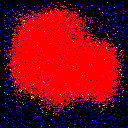

In [8]:
@torch.no_grad()
def sample(model, content_tensor):
    x_t = torch.randn_like(content_tensor)
    for t_idx in reversed(range(NUM_TIMESTEPS)):
        t = torch.tensor([t_idx], device=DEVICE)
        eps_pred = model(torch.cat([x_t, content_tensor], dim=1), t)

        alpha_t = alphas[t_idx]
        alpha_bar_t = alpha_bars[t_idx]
        beta_t = betas[t_idx]

        mean = (x_t - (beta_t / (1 - alpha_bar_t).sqrt()) * eps_pred) / alpha_t.sqrt()
        if t_idx > 0:
            x_t = mean + beta_t.sqrt() * torch.randn_like(x_t)
        else:
            x_t = mean

    return x_t.clamp(0.0, 1.0)

model.eval()
styled_tensor = sample(model, content_tensor)
model.train()

styled_image = postprocess(styled_tensor.squeeze(0).cpu())
styled_image

## Save + compare

Saved styled image to /Users/jackblackburn/code/main/audio_video/style-transfer/py/outputs/quick_test/diffusion_experiment/lily6_kanagawa_diffusion.jpg


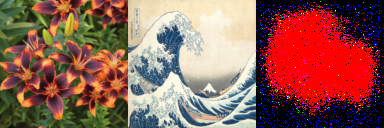

In [9]:
out_path = OUTPUT_DIR / "lily6_kanagawa_diffusion.jpg"
styled_image.save(out_path)
print(f"Saved styled image to {out_path}")

side_by_side(content_tensor, style_tensor, styled_tensor)

## Notes / next steps

This is a single-image overfit sanity check, not a usable style transfer model. What it's meant to answer: *does `perceptual_loss`, unmodified, provide a coherent gradient signal through a diffusion model's predicted-x0?* Judge that from the loss curve above (does `perceptual` trend down alongside `mse`?) and from whether the sampled output shows any Kanagawa-wave texture/color influence over the plain lily reconstruction.

If the signal looks useful, the next real steps would be:

- Train on a real content dataset (e.g. `artifacts/images/content/flowers`) instead of one image, so the model actually learns to generalize rather than memorize.
- A less minimal UNet (attention at low resolution, more levels/skip connections) — this one drops the highest-resolution skip connection entirely for simplicity.
- More timesteps and/or a cosine beta schedule; `NUM_TIMESTEPS=200` with a linear schedule is a coarse approximation.
- Only applying the perceptual loss term for a subset of timesteps (e.g. low-noise ones), since `x0_pred` from a heavily-noised `x_t` is a poor estimate early in the reverse process and may just add noise to the gradient.
- If this graduates beyond an experiment, it belongs in `style_transfer/` as its own module (e.g. `style_transfer/diffusion.py`) behind the same config-driven experiment system the feed-forward model uses — not hardcoded here.